In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import boxcox


In [2]:
data = {
    'Student_ID': range(1,10),
    'CNS_Score': [85, 90, 88, 92, np.nan, 78, 95, 82, 91],
    'DSBDA_Score': [78, 85, 89, 92, 80, np.nan, 75, 85,  np.nan],
    'Attendance': [90, 85, 88, 92, 80, 75, 95, 85, 90,]
}


In [3]:
df = pd.DataFrame(data)

In [4]:
df

,Student_ID,CNS_Score,DSBDA_Score,Attendance
0,1,85.0,78.0,90
1,2,90.0,85.0,85
2,3,88.0,89.0,88
3,4,92.0,92.0,92
4,5,NaN,80.0,80
5,6,78.0,NaN,75
6,7,95.0,75.0,95
7,8,82.0,85.0,85
8,9,91.0,NaN,90


In [5]:
print(df.isnull().sum())

Student_ID     0
CNS_Score      1
DSBDA_Score    2
Attendance     0
dtype: int64


In [21]:
df['CNS_Score'] = df['CNS_Score'].fillna(df['CNS_Score'].mean())
df['DSBDA_Score'] = df['DSBDA_Score'].fillna(df['DSBDA_Score'].mean())

In [22]:
print(df.isnull().sum())

Student_ID          0
CNS_Score           0
DSBDA_Score         0
Attendance          0
CNS_Score_BoxCox    0
dtype: int64


In [23]:
df

,Student_ID,CNS_Score,DSBDA_Score,Attendance,CNS_Score_BoxCox
0,1,85.000,78.000000,90,1.664049e+09
1,2,90.000,85.000000,85,2.233366e+09
2,3,88.000,89.000000,88,1.989370e+09
3,4,92.000,92.000000,92,2.500922e+09
4,5,87.625,80.000000,80,1.946111e+09
5,6,78.000,83.428571,75,1.069097e+09
6,7,95.000,75.000000,95,2.950140e+09
7,8,82.000,85.000000,85,1.383024e+09
8,9,91.000,83.428571,90,2.364096e+09


In [24]:
numeric_cols = ['CNS_Score', 'DSBDA_Score', 'Attendance']



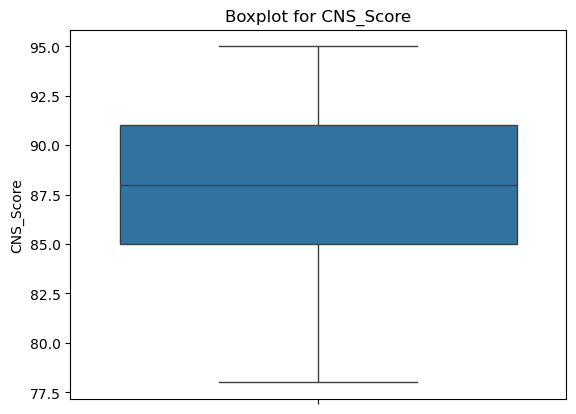

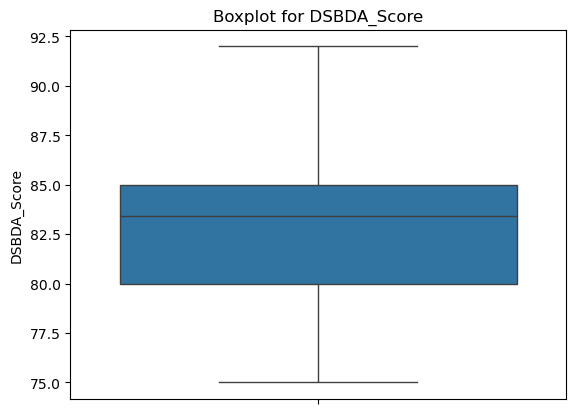

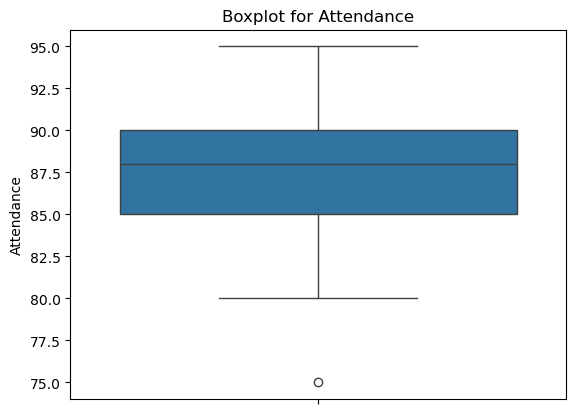

In [25]:
for col in numeric_cols:
    sns.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import boxcox


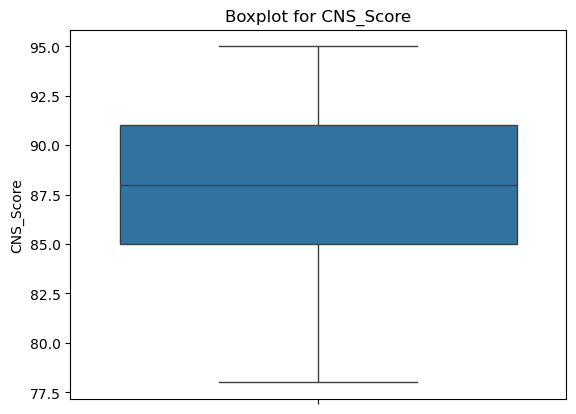

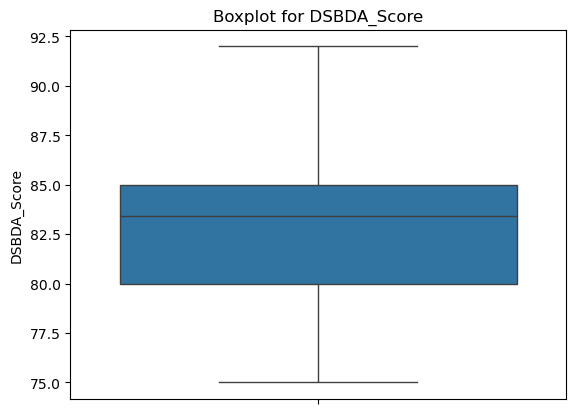

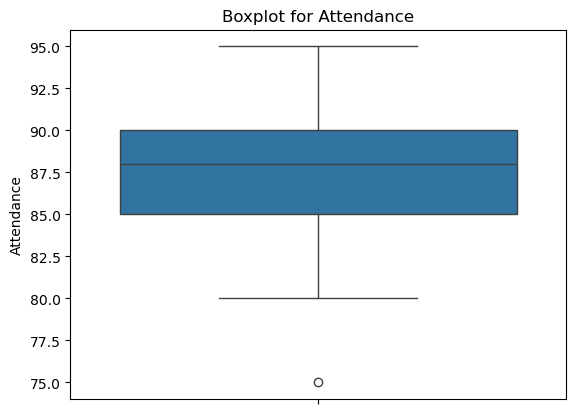

In [27]:
for col in numeric_cols:
    sns.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [13]:
z_scores = np.abs(zscore(df[numeric_cols]))

In [14]:
outlier_threshold = 3

In [15]:
outliers = (z_scores > outlier_threshold).any(axis=1)

In [16]:
print(f"\nRows with outliers:\n{df[outliers]}")


Rows with outliers:
Empty DataFrame
Columns: [Student_ID, CNS_Score, DSBDA_Score, Attendance]
Index: []


In [17]:
df['CNS_Score_BoxCox'], lambda_val = boxcox(df['CNS_Score'])
print(f"\nBox-Cox transformation applied to 'Study_Hours' with lambda = {lambda_val:.4f}")



Box-Cox transformation applied to 'Study_Hours' with lambda = 5.1481


<Axes: xlabel='CNS_Score_BoxCox', ylabel='Density'>

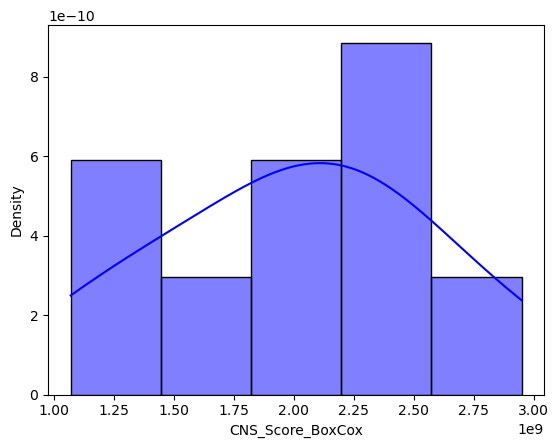

In [18]:
sns.histplot(df['CNS_Score_BoxCox'], kde=True, color='blue', label='Original', stat="density")

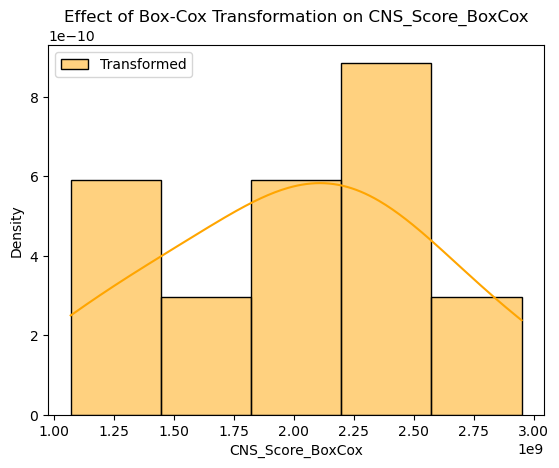


Final Dataset after Data Wrangling:
   Student_ID  CNS_Score  DSBDA_Score  Attendance  CNS_Score_BoxCox
0           1     85.000    78.000000          90      1.664049e+09
1           2     90.000    85.000000          85      2.233366e+09
2           3     88.000    89.000000          88      1.989370e+09
3           4     92.000    92.000000          92      2.500922e+09
4           5     87.625    80.000000          80      1.946111e+09
5           6     78.000    83.428571          75      1.069097e+09
6           7     95.000    75.000000          95      2.950140e+09
7           8     82.000    85.000000          85      1.383024e+09
8           9     91.000    83.428571          90      2.364096e+09


In [19]:
sns.histplot(df['CNS_Score_BoxCox'], kde=True, color='orange', label='Transformed', stat="density")
plt.legend()
plt.title("Effect of Box-Cox Transformation on CNS_Score_BoxCox")
plt.show()
print("\nFinal Dataset after Data Wrangling:")
print(df)
